# Q8.
```{admonition}
:class: note
In this exercise, we will generate simulated data, and will then use this data to perform forward and backward stepwise selection.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt

## (a)
```{admonition}
:class: note
Create a random number generator and use its `normal()` method to generate a predictor $X$ of length $n = 100$, as well as a noise vector $\varepsilon$ of length $n = 100$.

In [3]:
rng = np.random.default_rng(1728)
X = rng.normal(size=100)
e = rng.normal(size=100)

## (b)
```{admonition}
:class: note
Generate a response vector $Y$ of length $n = 100$ according to the model $Y = \beta_{0} + \beta_{1}X + \beta_{2}X^{2} + \beta_{3}X^{3} + \varepsilon$, where $\beta_{0}, \beta_{1}, \beta_{2}, \beta_{3}$ are constants.

In [4]:
B = np.array([1,2,-3,4])
Y = np.matmul(X[:,None]**np.arange(0,4),B)+e

## (c)
```{admonition}
:class: note
Use forward stepwise selection in order to select a model containing the predictors $X, X^{2}, \dots , X^{10}$. What is the model obtained according to $C_{p}$? Report the coefficients of the model obtained.

In [5]:
df_poly = pd.DataFrame(PolynomialFeatures(10,include_bias=False).fit_transform(X.reshape(-1,1)), columns=[f'X{i}' for i in range(1,11)])
df_poly['Y'] = Y

In [6]:
features = df_poly.columns[:-1]
selected_features = []
models = [Y.mean()]

for _ in range(10):
    best_mse = np.inf

    for feat in features:
        if feat in selected_features:
            continue
        current_features = selected_features+[feat]
        Xt = df_poly[current_features]
        Yt = df_poly['Y']
        model = LinearRegression().fit(Xt,Yt)
        mse = mean_squared_error(Yt,model.predict(Xt))
        if mse < best_mse:
            best_mse = mse
            best_feat = feat
            best_model = model
    selected_features.append(best_feat)
    models.append((best_model,selected_features.copy()))

In [7]:
features = df_poly.columns[:-1]
models = [df_poly['Y'].mean()]
feats_used = []

unused_features = set(features)
for _ in range(10):
    temp_models = {}
    best_mse = np.inf
    for feat in unused_features:
        X1 = df_poly[feats_used+[feat]]
        Y1 = df_poly['Y']
        lr = LinearRegression()
        lrfit = lr.fit(X1,Y1)
        mse = mean_squared_error(Y1,lrfit.predict(X1))
        best_mse = min(best_mse,mse)
        temp_models[mse] = (lrfit,feat)
    feats_used.append(temp_models[best_mse][1])
    models.append((temp_models[best_mse][0],feats_used.copy()))
    unused_features.discard(temp_models[best_mse][1])

In [8]:
best_C_p = np.inf
# full_model = models[9]
# full_preds = full_model[0].predict(df_poly[full_model[1]])
# full_RSS = np.sum((Y-full_preds)**2)
# s = full_RSS/(Y.shape[0]-len(full_model[1])-1)
# Already know errors are N(0,1) so estimation not strictly needed

for model in models[1:]:
    preds = model[0].predict(df_poly[model[1]])
    RSS = np.sum((Y-preds)**2)
    p = len(model[1])+1
#    C_p = (RSS+2*p*s)/Y.shape[0]
    C_p = (RSS+2*p*1)/Y.shape[0]
    if C_p < best_C_p:
        best_C_p = C_p
        best_model = model
print(best_model)
print([best_model[0].intercept_]+best_model[0].coef_.tolist())
print(B)

(LinearRegression(), ['X3', 'X2', 'X1'])
[np.float64(1.176750370287563), 3.9526762706552026, -3.0330323083466957, 2.1322799378270156]
[ 1  2 -3  4]


## (d)
```{admonition}
:class: note
Repeat (c), using backwards stepwise selection. How does your answer compare to the results in (c)?

In [9]:
features = list(df_poly.columns[:-1])
selected_features = features.copy()
models = []

for _ in range(9):
    best_mse = np.inf

    for feat in selected_features:
        current_features = [f for f in selected_features if f!=feat]
        Xt = df_poly[current_features]
        Yt = df_poly['Y']
        model = LinearRegression().fit(Xt,Yt)
        mse = mean_squared_error(Yt,model.predict(Xt))
        if mse < best_mse:
            best_mse = mse
            remove_feat = feat
            best_model = model
    selected_features.remove(remove_feat)
    models.append((best_model,selected_features.copy()))
models.append(Y.mean())

In [10]:
best_C_p = np.inf

for model in models[:-1]:
    preds = model[0].predict(df_poly[model[1]])
    RSS = np.sum((Y-preds)**2)
    p = len(model[1])+1
    C_p = (RSS+2*p*1)/Y.shape[0]
    if C_p < best_C_p:
        best_C_p = C_p
        best_model = model
print(best_model)
print([best_model[0].intercept_]+best_model[0].coef_.tolist())
print(B)

(LinearRegression(), ['X1', 'X2', 'X3'])
[np.float64(1.176750370287563), 2.132279937827011, -3.0330323083466952, 3.9526762706552008]
[ 1  2 -3  4]


## (e)
```{admonition}
:class: note
Now fit a lasso model to the simulated data, again using $X, X^{2}, \dots , X^{10}$ as predictors. Use cross-validation to select the optimal value of $\lambda$. Create plots of the cross-validation error as a function of $\lambda$. Report the resulting coefficient estimates.

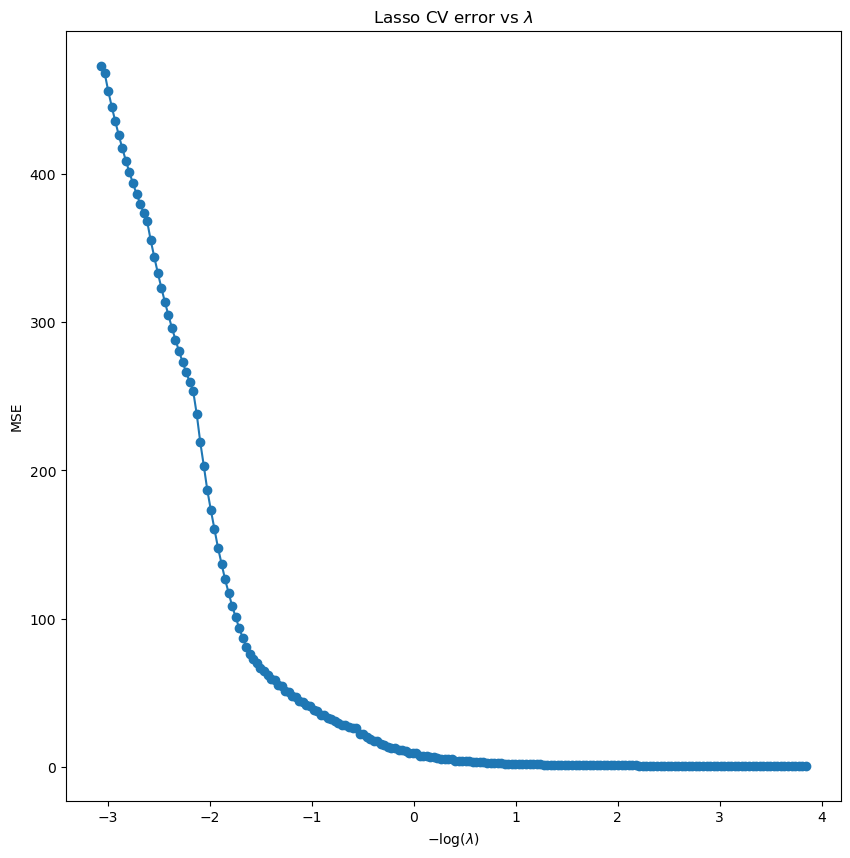

In [11]:
ls = LassoCV(alphas=200,cv=5,random_state=1728)
scalar = StandardScaler()
ls.fit(scalar.fit_transform(df_poly.drop(columns=['Y'])),Y)
mse_means = np.mean(ls.mse_path_,axis=1)
plt.figure(figsize=(10,10))
plt.plot(-np.log(ls.alphas_),mse_means,marker='o')
plt.xlabel("$-\\log(\\lambda$)")
plt.ylabel('MSE')
plt.title("Lasso CV error vs $\\lambda$")
plt.show()

In [12]:
print(ls.coef_/scalar.scale_)
print(ls.intercept_-np.matmul(ls.coef_.T,scalar.mean_/scalar.scale_))

[ 2.13473807e+00 -3.00878043e+00  3.94393167e+00 -0.00000000e+00
  5.85714309e-05  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
1.1510515151972804


## (f)
```{admonition}
:class: note
Now generate a response vector $Y$ according to the model
$$
Y = \beta_{0} + \beta_{7}X^{7} + \varepsilon,
$$
and perform forward stepwise selection and the lasso.

In [13]:
Y = 5+20*X**7+e

In [14]:
df_poly = pd.DataFrame(PolynomialFeatures(10,include_bias=False).fit_transform(X.reshape(-1,1)), columns=[f'X{i}' for i in range(1,11)])
df_poly['Y'] = Y

In [15]:
features = df_poly.columns[:-1]
selected_features = []
models = [Y.mean()]

for _ in range(10):
    best_mse = np.inf

    for feat in features:
        if feat in selected_features:
            continue
        current_features = selected_features+[feat]
        Xt = df_poly[current_features]
        Yt = df_poly['Y']
        model = LinearRegression().fit(Xt,Yt)
        mse = mean_squared_error(Yt,model.predict(Xt))
        if mse < best_mse:
            best_mse = mse
            best_feat = feat
            best_model = model
    selected_features.append(best_feat)
    models.append((best_model,selected_features.copy()))

In [16]:
best_C_p = np.inf

for model in models[1:]:
    preds = model[0].predict(df_poly[model[1]])
    RSS = np.sum((Y-preds)**2)
    p = len(model[1])+1
#    C_p = (RSS+2*p*s)/Y.shape[0]
    C_p = (RSS+2*p*1)/Y.shape[0]
    if C_p < best_C_p:
        best_C_p = C_p
        best_model = model
print(best_model)
print([best_model[0].intercept_]+best_model[0].coef_.tolist())

(LinearRegression(), ['X7'])
[np.float64(5.141653532150713), 19.999705955381568]


In [17]:
ls = LassoCV(alphas=2000,cv=10,random_state=1728)
scalar = StandardScaler()
ls.fit(scalar.fit_transform(df_poly.drop(columns=['Y'])),Y)
print(ls.coef_/scalar.scale_)
print(ls.intercept_-np.matmul(ls.coef_.T,scalar.mean_/scalar.scale_))

[-21.45922874  -0.73180968   0.          -0.          25.16700436
   0.          13.91022971   0.           0.32861989   0.        ]
-0.5148241961296662


In [ ]:
pipe = Pipeline([('poly',
    PolynomialFeatures(degree=10,include_bias=False)),
    ('scale',StandardScaler()),
    ('lasso',LassoCV(cv=5,random_state=1728,alphas=np.logspace(-2,4,2000),max_iter=10000))]
)
pipe.fit(X.reshape(-1,1),Y)
pipe.named_steps['lasso'].coef_/pipe.named_steps['scale'].scale_

array([-45.98183265,  -0.        ,  -0.62213695,  -3.88880458,
        28.21586376,  -0.        ,  13.16526497,  -0.        ,
         0.37876527,  -0.        ])

In [19]:
ls.alpha_

np.float64(13.746184859209567)

In [20]:
pipe.named_steps['lasso'].alpha_

np.float64(2.5538983163273032)